# 2.0 Full EIP-7999 Three-Resource Equilibrium

This notebook extends the independent isoelastic demand estimates from notebook 1.8 to full EIP-7999. Execution, data, and state each have a separate base fee, so each fee is solved by requiring its resource demand to equal its own target.

The central capacity assumptions are:

- execution limits of 100M, 200M, and 450M gas, with targets at one half of the limit;
- data limits of 40M, 60M, and 90M gas, with targets at one quarter of the limit;
- a 75M state-gas target and no state-gas limit;
- the 35-day independent isoelastic estimates as central, with 21-, 60-, and 75-day estimates as robustness checks;
- the full calibrated BAL amount in the data resource, with separate BAL sensitivity; and
- no EIP-7918 reserve condition in this first equilibrium calculation; and
- $m_{\mathrm{execution}}=1$: EIP-8038 state-access repricing is not yet included in regular execution gas.

The paired capacity packages are 100M execution/40M data, 200M execution/60M data, and the 450M execution/90M data scaling case. The 100M and 200M cases are the primary Glamsterdam comparisons; 450M is an exploratory scaling case. The 40M data limit is close to the 3-second `conservative_p90` capacity in notebook 0.2; the 60M and 90M limits are rounded versions of its 3-second `empirical_p90` capacities. The `glamsterdam_plus_8279` worst-case payload calculation is retained as a diagnostic; it does not replace the independent data limit under full 7999.

In [1]:
from itertools import product
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from bandwidth_limits.propagation import CONSERVATIVE_P90, EMPIRICAL_P90, safe_payload_bytes
from bandwidth_limits.scenarios import GLAMSTERDAM_PLUS_8279
from bandwidth_limits.sweep import best_strategy_sweep
from basefee.eip7999_normalized import (
    ResourceFeeConfig,
    compute_base_fee,
    excess_gas_for_base_fee,
)

pd.options.display.float_format = "{:,.6f}".format
plt.style.use("seaborn-v0_8-whitegrid")

DATA_DIR = PROJECT_ROOT / "data"
PLOTS_DIR = PROJECT_ROOT / "plots"
DATE_LABEL = "2026-02-01_2026-06-01"
GWEI = 1e9
MIN_BASE_FEE_WEI = 1
RESOURCES = ["execution", "data", "state"]

ACCOUNTING_PANEL_CSV = DATA_DIR / f"daily_accounting_panel_calibrated_with_bal_{DATE_LABEL}.csv"
CURRENT_DATA_CSV = DATA_DIR / f"daily_current_data_gas_xatu_{DATE_LABEL}.csv"
ELASTICITY_CSV = DATA_DIR / "three_way_isoelastic_calibration_2025.csv"
G0_HEADLINE_CSV = DATA_DIR / f"three_way_equilibrium_headline_{DATE_LABEL}.csv"

OUT_CAPACITY_CSV = DATA_DIR / f"full_7999_equilibrium_capacity_card_{DATE_LABEL}.csv"
OUT_PAYLOAD_CHECK_CSV = DATA_DIR / f"full_7999_equilibrium_execution_payload_check_{DATE_LABEL}.csv"
OUT_ACCOUNTING_CSV = DATA_DIR / f"full_7999_equilibrium_accounting_card_{DATE_LABEL}.csv"
OUT_RESULTS_CSV = DATA_DIR / f"full_7999_equilibrium_results_{DATE_LABEL}.csv"
OUT_HEADLINE_CSV = DATA_DIR / f"full_7999_equilibrium_headline_{DATE_LABEL}.csv"
OUT_WINDOW_CSV = DATA_DIR / f"full_7999_equilibrium_window_sensitivity_{DATE_LABEL}.csv"
OUT_BAL_CSV = DATA_DIR / f"full_7999_equilibrium_bal_sensitivity_{DATE_LABEL}.csv"

## Capacity Card

The propagation calculation and the execution worst-case calculation answer different questions.

1. The propagation fits ask how many payload bytes fit within the assumed propagation budget. At 16 data gas per byte, the 3-second `conservative_p90` full-window capacity is approximately 40.8M gas. The `empirical_p90` capacities are approximately 62.2M gas with a 0.75 safety factor and 89.9M gas with the full window. These motivate rounded 40M, 60M, and 90M data limits.
2. `glamsterdam_plus_8279` asks how many bytes can be induced by a full execution block under that Glamsterdam gas schedule. This is a diagnostic for the 100M, 200M, and 450M execution limits, not a full-7999 execution-to-bytes bound: the 64-gas-per-byte floors used by the check are deprecated in the full-7999 world modeled here. The separate data limit remains the authoritative payload bound. The 100M/40M, 200M/60M, and 450M/90M pairings are capacity packages chosen for comparison; propagation does not mechanically pair a data limit with an execution limit.

In [2]:
EXECUTION_LIMITS = [100_000_000, 200_000_000, 450_000_000]
DATA_LIMITS = [40_000_000, 60_000_000, 90_000_000]
STATE_TARGET = 75_000_000
EXECUTION_TARGET_RATIO = 2
DATA_TARGET_RATIO = 4
DATA_GAS_PER_BYTE = 16
PROPAGATION_WINDOW_MS = 3_000
PAIRED_DATA_LIMIT = {
    100_000_000: 40_000_000,
    200_000_000: 60_000_000,
    450_000_000: 90_000_000,
}

capacity_specs = [
    (CONSERVATIVE_P90, 1.00, 40_000_000),
    (EMPIRICAL_P90, 0.75, 60_000_000),
    (EMPIRICAL_P90, 1.00, 90_000_000),
]
capacity_rows = []
for propagation_fit, safety_factor, rounded_limit in capacity_specs:
    safe_bytes = safe_payload_bytes(
        PROPAGATION_WINDOW_MS, propagation_fit, safety_factor
    )
    exact_limit = DATA_GAS_PER_BYTE * safe_bytes
    capacity_rows.append({
        "propagation_fit": propagation_fit.name,
        "window_ms": PROPAGATION_WINDOW_MS,
        "safety_factor": safety_factor,
        "safe_payload_bytes": safe_bytes,
        "exact_data_gas_limit": exact_limit,
        "rounded_data_gas_limit": rounded_limit,
        "rounded_data_target": rounded_limit / DATA_TARGET_RATIO,
        "rounding_error_pct": 100 * (rounded_limit / exact_limit - 1),
    })
capacity_card = pd.DataFrame(capacity_rows)
capacity_card.to_csv(OUT_CAPACITY_CSV, index=False)
display(capacity_card)

payload_check = best_strategy_sweep(
    EXECUTION_LIMITS, [GLAMSTERDAM_PLUS_8279]
).copy()
payload_check["paired_data_gas_limit"] = payload_check["execution_gas_limit"].map(PAIRED_DATA_LIMIT)
payload_check["paired_data_byte_limit"] = payload_check["paired_data_gas_limit"] / DATA_GAS_PER_BYTE
payload_check["execution_implied_data_gas"] = payload_check["total_payload_bytes"] * DATA_GAS_PER_BYTE
payload_check["payload_pct_paired_data_limit"] = (
    payload_check["execution_implied_data_gas"] / payload_check["paired_data_gas_limit"]
)
payload_cols = [
    "execution_gas_limit", "schedule", "best_strategy",
    "total_payload_bytes", "total_payload_mib",
    "execution_implied_data_gas", "paired_data_gas_limit",
    "paired_data_byte_limit", "payload_pct_paired_data_limit",
]
payload_check[payload_cols].to_csv(OUT_PAYLOAD_CHECK_CSV, index=False)
display(payload_check[payload_cols])

,propagation_fit,window_ms,safety_factor,safe_payload_bytes,exact_data_gas_limit,rounded_data_gas_limit,rounded_data_target,rounding_error_pct
0,conservative_p90,3000,1.000000,2552761,40844176,40000000,"10,000,000.000000",-2.066821
1,empirical_p90,3000,0.750000,3885652,62170432,60000000,"15,000,000.000000",-3.491100
2,empirical_p90,3000,1.000000,5619286,89908576,90000000,"22,500,000.000000",0.101686


,execution_gas_limit,schedule,best_strategy,total_payload_bytes,total_payload_mib,execution_implied_data_gas,paired_data_gas_limit,paired_data_byte_limit,payload_pct_paired_data_limit
0,100000000,glamsterdam_plus_8279,all_calldata_nonzero,1562171,1.489802,24994736,40000000,"2,500,000.000000",0.624868
1,200000000,glamsterdam_plus_8279,all_calldata_nonzero,3124671,2.979918,49994736,60000000,"3,750,000.000000",0.833246
2,450000000,glamsterdam_plus_8279,all_calldata_nonzero,7030921,6.705209,112494736,90000000,"5,625,000.000000",1.249942


## 120-Day Demand And Metering Anchor

The demand elasticities were estimated using three historical gas-equivalent quantities. To transport those curves into 7999, the same physical activity is converted into each candidate resource's gas units.

For each resource, let $q_i^0$ be its historical gas-equivalent quantity and let $m_i$ convert that quantity into 7999 gas. The metered anchor is $g_i^0=m_iq_i^0$. A reference 7999 fee of $p_i^0=b_{\mathrm{ref}}/m_i$ preserves the historical effective price of that activity.

The data conversion includes calldata, access lists, authorization tuples, blob hashes, and estimated BAL RLP bytes at 16 gas per byte. Because BALs are generated by transaction execution rather than chosen as standalone data, applying the data elasticity to the combined data resource is a transport assumption. The later BAL sensitivity makes its importance visible.

In [3]:
accounting = pd.read_csv(ACCOUNTING_PANEL_CSV)
current_data = pd.read_csv(CURRENT_DATA_CSV)[["date", "data_gas_current"]]
accounting = accounting.merge(current_data, on="date", how="left", validate="one_to_one")
if accounting["data_gas_current"].isna().any():
    raise ValueError("Current-rule data gas is missing for one or more days")

blocks = float(accounting["block_count"].sum())
BASE_FEE_REF = float(accounting["median_base_fee_per_gas"].median())
current_data_total = float(accounting["data_gas_current"].sum())
current_state_total = float(accounting["current_state_creation_gas_calibrated"].sum())
current_execution_total = float(
    accounting["current_gas_used"].sum() - current_data_total - current_state_total
)
data_7999_no_bal_total = float(accounting["bandwidth_gas_16_calibrated_no_bal"].sum())
data_7999_with_bal_total = float(accounting["bandwidth_gas_16_calibrated_with_bal"].sum())
bal_7999_total = data_7999_with_bal_total - data_7999_no_bal_total
state_7999_total = float(accounting["state_gas_8037_calibrated"].sum())

ANCHOR_QUANTITIES = {
    "execution": current_execution_total / blocks,
    "data": current_data_total / blocks,
    "state": current_state_total / blocks,
}
METERING_MULTIPLIERS = {
    "execution": 1.0,
    "data": data_7999_with_bal_total / current_data_total,
    "state": state_7999_total / current_state_total,
}
ANCHOR_METERED_GAS = {
    name: ANCHOR_QUANTITIES[name] * METERING_MULTIPLIERS[name]
    for name in RESOURCES
}
REFERENCE_FEES_WEI = {
    name: BASE_FEE_REF / METERING_MULTIPLIERS[name]
    for name in RESOURCES
}

accounting_card = pd.DataFrame([{
    "start_date": accounting["date"].min(),
    "end_date": accounting["date"].max(),
    "days": len(accounting),
    "blocks": blocks,
    "historical_base_fee_ref_gwei": BASE_FEE_REF / GWEI,
    "execution_historical_quantity_per_block": ANCHOR_QUANTITIES["execution"],
    "data_historical_quantity_per_block": ANCHOR_QUANTITIES["data"],
    "state_historical_quantity_per_block": ANCHOR_QUANTITIES["state"],
    "execution_7999_gas_per_block": ANCHOR_METERED_GAS["execution"],
    "data_7999_gas_no_bal_per_block": data_7999_no_bal_total / blocks,
    "bal_7999_gas_per_block": bal_7999_total / blocks,
    "data_7999_gas_with_bal_per_block": ANCHOR_METERED_GAS["data"],
    "state_7999_gas_per_block": ANCHOR_METERED_GAS["state"],
    "data_metering_multiplier_with_bal": METERING_MULTIPLIERS["data"],
    "state_metering_multiplier": METERING_MULTIPLIERS["state"],
    "bal_share_of_7999_data_gas": bal_7999_total / data_7999_with_bal_total,
    "execution_reference_fee_gwei": REFERENCE_FEES_WEI["execution"] / GWEI,
    "data_reference_fee_gwei": REFERENCE_FEES_WEI["data"] / GWEI,
    "state_reference_fee_gwei": REFERENCE_FEES_WEI["state"] / GWEI,
}])
accounting_card.to_csv(OUT_ACCOUNTING_CSV, index=False)
display(accounting_card.T)

,0
start_date,2026-02-01
end_date,2026-05-31
days,120
blocks,"860,505.000000"
historical_base_fee_ref_gwei,0.106928
execution_historical_quantity_per_block,"23,942,241.363434"
data_historical_quantity_per_block,"1,180,555.063055"
state_historical_quantity_per_block,"5,244,154.703798"
execution_7999_gas_per_block,"23,942,241.363434"
data_7999_gas_no_bal_per_block,"2,123,622.489873"


## Independent Isoelastic Elasticities

Notebook 1.8 recovers separate execution, data, and state elasticities from the clean 2025 gas-limit events. The 35-day estimates are central. All four available window lengths are retained here because the equilibrium fee can be very sensitive when an elasticity is small. No aggregate-plus-softmax result is used in this notebook.

In [4]:
elasticities = pd.read_csv(ELASTICITY_CSV).sort_values("window_days")
WINDOW_DAYS = elasticities["window_days"].astype(int).tolist()
CENTRAL_WINDOW = 35
if CENTRAL_WINDOW not in WINDOW_DAYS:
    raise ValueError("35-day elasticity calibration is missing")
if (elasticities[[f"eps_{name}" for name in RESOURCES]] <= 0).any().any():
    raise ValueError("All independent elasticities must be positive")
display(elasticities[[
    "window_days", "eps_agg", "eps_execution", "eps_data", "eps_state"
]])

,window_days,eps_agg,eps_execution,eps_data,eps_state
0,21,0.194893,0.117067,0.201790,0.478438
1,35,0.169292,0.121160,0.229476,0.334864
2,60,0.127086,0.081668,0.204691,0.279676
3,75,0.119173,0.078511,0.201391,0.253556


## Target-Clearing Fee For A Separate Resource

For a resource with metered anchor $g_i^0$, reference fee $p_i^0$, and own-price elasticity $\epsilon_i$, demand in 7999 gas is

$$g_i(p_i)=g_i^0\left(\frac{p_i}{p_i^0}\right)^{-\epsilon_i}. $$

Setting $g_i(p_i^*)=T_i$ gives an analytical equilibrium fee:

$$p_i^*=p_i^0\left(\frac{g_i^0}{T_i}\right)^{1/\epsilon_i}. $$

This separates the three equilibrium calculations completely. The EIP-4844-style fake exponential determines how the protocol moves toward the fee and how excess gas maps to integer wei; it does not change the continuous target-clearing condition. We therefore report both the continuous solution and the nearest integer protocol fee, together with the target error caused by integer quantization.

In [5]:
def resource_config(resource, execution_limit, data_limit):
    if resource == "execution":
        return ResourceFeeConfig(
            name=resource, gas_limit=int(execution_limit),
            gas_target=int(execution_limit // EXECUTION_TARGET_RATIO),
            min_base_fee=MIN_BASE_FEE_WEI,
        )
    if resource == "data":
        return ResourceFeeConfig(
            name=resource, gas_limit=int(data_limit),
            gas_target=int(data_limit // DATA_TARGET_RATIO),
            min_base_fee=MIN_BASE_FEE_WEI, reserve_mode="none",
        )
    if resource == "state":
        return ResourceFeeConfig(
            name=resource, gas_limit=None, gas_target=STATE_TARGET,
            normalization_denominator=STATE_TARGET,
            min_base_fee=MIN_BASE_FEE_WEI,
        )
    raise ValueError(resource)


def metered_demand(base_fee_wei, *, anchor_metered_gas, reference_fee_wei, elasticity):
    return anchor_metered_gas * (base_fee_wei / reference_fee_wei) ** (-elasticity)


def nearest_protocol_fee(continuous_fee_wei, *, config, anchor_metered_gas, reference_fee_wei, elasticity):
    lower = max(MIN_BASE_FEE_WEI, math.floor(continuous_fee_wei))
    upper = max(MIN_BASE_FEE_WEI, math.ceil(continuous_fee_wei))
    candidates = []
    for requested_fee in sorted({lower, upper}):
        excess = excess_gas_for_base_fee(int(requested_fee), config)
        represented_fee = compute_base_fee(excess, config)
        usage = metered_demand(
            represented_fee, anchor_metered_gas=anchor_metered_gas,
            reference_fee_wei=reference_fee_wei, elasticity=elasticity,
        )
        candidates.append({
            "protocol_base_fee_wei": represented_fee,
            "warm_start_excess_gas": excess,
            "metered_at_protocol_fee": usage,
            "absolute_target_error": abs(usage - config.gas_target),
        })
    return min(candidates, key=lambda row: row["absolute_target_error"])


def solve_resource(*, resource, elasticity, execution_limit, data_limit,
                   anchor_quantity=None, metering_multiplier=None):
    config = resource_config(resource, execution_limit, data_limit)
    q0 = ANCHOR_QUANTITIES[resource] if anchor_quantity is None else float(anchor_quantity)
    multiplier = (METERING_MULTIPLIERS[resource]
                  if metering_multiplier is None else float(metering_multiplier))
    anchor_metered = q0 * multiplier
    reference_fee = BASE_FEE_REF / multiplier
    continuous_fee = reference_fee * (anchor_metered / config.gas_target) ** (1 / elasticity)
    continuous_metered = metered_demand(
        continuous_fee, anchor_metered_gas=anchor_metered,
        reference_fee_wei=reference_fee, elasticity=elasticity,
    )
    protocol = nearest_protocol_fee(
        continuous_fee, config=config, anchor_metered_gas=anchor_metered,
        reference_fee_wei=reference_fee, elasticity=elasticity,
    )
    return {
        "resource": resource,
        "gas_limit": config.gas_limit,
        "gas_target": config.gas_target,
        "elasticity": elasticity,
        "anchor_historical_quantity": q0,
        "metering_multiplier": multiplier,
        "anchor_metered_gas": anchor_metered,
        "reference_base_fee_gwei": reference_fee / GWEI,
        "equilibrium_base_fee_wei_continuous": continuous_fee,
        "equilibrium_base_fee_gwei": continuous_fee / GWEI,
        "effective_equilibrium_fee_gwei": multiplier * continuous_fee / GWEI,
        "metered_at_continuous_fee": continuous_metered,
        "continuous_target_error_pct": 100 * (continuous_metered / config.gas_target - 1),
        "minimum_fee_binding": continuous_fee < MIN_BASE_FEE_WEI,
        "protocol_base_fee_wei": protocol["protocol_base_fee_wei"],
        "protocol_base_fee_gwei": protocol["protocol_base_fee_wei"] / GWEI,
        "protocol_fee_at_minimum": protocol["protocol_base_fee_wei"] == MIN_BASE_FEE_WEI,
        "warm_start_excess_gas": protocol["warm_start_excess_gas"],
        "metered_at_protocol_fee": protocol["metered_at_protocol_fee"],
        "protocol_target_error_pct": 100 * (protocol["metered_at_protocol_fee"] / config.gas_target - 1),
    }


rows = []
for _, calibration in elasticities.iterrows():
    window_days = int(calibration["window_days"])
    for execution_limit, data_limit in product(EXECUTION_LIMITS, DATA_LIMITS):
        scenario = f"E{execution_limit//1_000_000}_D{data_limit//1_000_000}_S{STATE_TARGET//1_000_000}"
        paired = PAIRED_DATA_LIMIT[execution_limit] == data_limit
        for resource in RESOURCES:
            row = solve_resource(
                resource=resource, elasticity=float(calibration[f"eps_{resource}"]),
                execution_limit=execution_limit, data_limit=data_limit,
            )
            row.update({
                "scenario": scenario, "paired_capacity_scenario": paired,
                "window_days": window_days,
                "execution_gas_limit": execution_limit,
                "data_gas_limit": data_limit,
                "state_gas_target": STATE_TARGET,
                "bal_amount_ratio": 1.0,
            })
            rows.append(row)
results = pd.DataFrame(rows)

if not np.allclose(results["metered_at_continuous_fee"], results["gas_target"], rtol=1e-10):
    raise AssertionError("Continuous equilibrium does not clear every resource target")
for window_days in WINDOW_DAYS:
    check = results[results["window_days"].eq(window_days)]
    if check[check["resource"].eq("execution")].groupby("execution_gas_limit")["equilibrium_base_fee_gwei"].nunique().max() != 1:
        raise AssertionError("Execution fee should not depend on the data limit")
    if check[check["resource"].eq("data")].groupby("data_gas_limit")["equilibrium_base_fee_gwei"].nunique().max() != 1:
        raise AssertionError("Data fee should not depend on the execution limit")
    if check[check["resource"].eq("state")]["equilibrium_base_fee_gwei"].nunique() != 1:
        raise AssertionError("State fee should not depend on execution or data limits")
results.to_csv(OUT_RESULTS_CSV, index=False)
print("solved", results.shape, "resource equilibria")
print("continuous minimum-fee cases:", int(results["minimum_fee_binding"].sum()))
print("nearest protocol fee equals 1 wei:", int(results["protocol_fee_at_minimum"].sum()))

solved (108, 27) resource equilibria
continuous minimum-fee cases: 12
nearest protocol fee equals 1 wei: 15


## Central Full-7999 Equilibrium And Glamsterdam Bridge

The headline table uses the paired 100M-execution/40M-data, 200M-execution/60M-data, and 450M-execution/90M-data capacity packages with the 35-day elasticities. It places the first two 7999 cases beside the corresponding shared Glamsterdam equilibrium fee from notebook 1.9. The 450M case is the 7999 scaling scenario and has no 450M Glamsterdam headline comparator.

This is a parameter bridge, not yet an economic ranking. Glamsterdam has one target on `max(regular, state)`, whereas full 7999 clears three targets simultaneously. Raw base fees also price different gas units. Effective transaction-bundle costs and fee dynamics belong in the next comparison notebook.

In [6]:
central = results[
    results["window_days"].eq(CENTRAL_WINDOW)
    & results["paired_capacity_scenario"]
].copy()
fee_wide = central.pivot(index=[
    "scenario", "execution_gas_limit", "data_gas_limit", "state_gas_target"
], columns="resource", values="equilibrium_base_fee_gwei").reset_index()
fee_wide = fee_wide.rename(columns={
    "execution": "execution_target_clearing_fee_gwei_continuous",
    "data": "data_target_clearing_fee_gwei_continuous",
    "state": "state_target_clearing_fee_gwei_continuous",
})
effective_wide = central.pivot(
    index="scenario", columns="resource", values="effective_equilibrium_fee_gwei"
).reset_index().rename(columns={
    "execution": "execution_effective_fee_gwei",
    "data": "data_effective_fee_gwei",
    "state": "state_effective_fee_gwei",
})
protocol_wide = central.pivot(
    index="scenario", columns="resource", values="protocol_base_fee_wei"
).reset_index().rename(columns={
    "execution": "execution_protocol_base_fee_wei",
    "data": "data_protocol_base_fee_wei",
    "state": "state_protocol_base_fee_wei",
})
protocol_gwei_wide = central.pivot(
    index="scenario", columns="resource", values="protocol_base_fee_gwei"
).reset_index().rename(columns={
    "execution": "execution_protocol_base_fee_gwei",
    "data": "data_protocol_base_fee_gwei",
    "state": "state_protocol_base_fee_gwei",
})
floor_wide = central.pivot(
    index="scenario", columns="resource", values="minimum_fee_binding"
).reset_index().rename(columns={
    "execution": "execution_target_unreachable_at_minimum_fee",
    "data": "data_target_unreachable_at_minimum_fee",
    "state": "state_target_unreachable_at_minimum_fee",
})
protocol_error_wide = central.pivot(
    index="scenario", columns="resource", values="protocol_target_error_pct"
).reset_index().rename(columns={
    "execution": "execution_protocol_target_error_pct",
    "data": "data_protocol_target_error_pct",
    "state": "state_protocol_target_error_pct",
})
headline = (
    fee_wide.merge(effective_wide, on="scenario", validate="one_to_one")
    .merge(protocol_wide, on="scenario", validate="one_to_one")
    .merge(protocol_gwei_wide, on="scenario", validate="one_to_one")
    .merge(floor_wide, on="scenario", validate="one_to_one")
    .merge(protocol_error_wide, on="scenario", validate="one_to_one")
)
headline["execution_gas_target"] = headline["execution_gas_limit"] / EXECUTION_TARGET_RATIO
headline["data_gas_target"] = headline["data_gas_limit"] / DATA_TARGET_RATIO

g0 = pd.read_csv(G0_HEADLINE_CSV)
g0 = g0[g0["model"].eq("independent isoelastic (central)")][
    ["gas_limit_M", "equilibrium_base_fee_gwei", "binding_branch"]
].rename(columns={
    "gas_limit_M": "execution_limit_M_join",
    "equilibrium_base_fee_gwei": "glamsterdam_shared_base_fee_gwei",
    "binding_branch": "glamsterdam_binding_branch",
})
headline["execution_limit_M_join"] = headline["execution_gas_limit"] / 1e6
headline = headline.merge(g0, on="execution_limit_M_join", how="left", validate="one_to_one")
headline = headline.drop(columns="execution_limit_M_join")
headline["comparison_role"] = np.where(
    headline["execution_gas_limit"].eq(450_000_000),
    "7999 scaling case; no 450M Glamsterdam headline",
    "same numerical execution/bottleneck limit as Glamsterdam",
)
headline.to_csv(OUT_HEADLINE_CSV, index=False)
display(headline[[
    "scenario", "execution_gas_limit", "execution_gas_target",
    "data_gas_limit", "data_gas_target", "state_gas_target",
    "glamsterdam_shared_base_fee_gwei", "glamsterdam_binding_branch",
    "execution_target_clearing_fee_gwei_continuous",
    "data_target_clearing_fee_gwei_continuous",
    "state_target_clearing_fee_gwei_continuous",
    "execution_protocol_base_fee_gwei", "data_protocol_base_fee_gwei",
    "state_protocol_base_fee_gwei",
    "execution_protocol_base_fee_wei", "data_protocol_base_fee_wei",
    "state_protocol_base_fee_wei", "execution_target_unreachable_at_minimum_fee",
    "execution_protocol_target_error_pct", "comparison_role",
]])

,scenario,execution_gas_limit,execution_gas_target,data_gas_limit,data_gas_target,state_gas_target,glamsterdam_shared_base_fee_gwei,glamsterdam_binding_branch,execution_target_clearing_fee_gwei_continuous,data_target_clearing_fee_gwei_continuous,state_target_clearing_fee_gwei_continuous,execution_protocol_base_fee_gwei,data_protocol_base_fee_gwei,state_protocol_base_fee_gwei,execution_protocol_base_fee_wei,data_protocol_base_fee_wei,state_protocol_base_fee_wei,execution_target_unreachable_at_minimum_fee,execution_protocol_target_error_pct,comparison_role
0,E100_D40_S75,100000000,"50,000,000.000000",40000000,"10,000,000.000000",75000000,0.003975,state,0.000245,0.000709,0.001184,0.000245,0.000709,0.001184,245220,708790,1184471,False,-0.000024,same numerical execution/bottleneck limit as G...
1,E200_D60_S75,200000000,"100,000,000.000000",60000000,"15,000,000.000000",75000000,0.000502,state,0.000001,0.000121,0.001184,0.000001,0.000121,0.001184,803,121103,1184471,False,0.007427,same numerical execution/bottleneck limit as G...
2,E450_D90_S75,450000000,"225,000,000.000000",90000000,"22,500,000.000000",75000000,NaN,NaN,0.000000,0.000021,0.001184,0.000000,0.000021,0.001184,1,20692,1184471,True,-0.049719,7999 scaling case; no 450M Glamsterdam headline


## Event-Window Robustness

The points show the 21-, 35-, 60-, and 75-day independent estimates. The darker point is the 35-day central calibration, and the vertical bar spans the minimum and maximum continuous target-clearing fee across the four windows. A log axis is necessary because the low execution elasticity makes the 200M execution case approach one wei and puts every 450M execution estimate below the one-wei protocol minimum. The dashed line marks that minimum; points below it are theoretical fees, not feasible protocol equilibria.

resource,scenario,execution_gas_limit,data_gas_limit,window_days,data_base_fee_gwei,execution_base_fee_gwei,state_base_fee_gwei
0,E100_D40_S75,100000000,40000000,21,0.000424,0.000198,0.002720
1,E100_D40_S75,100000000,40000000,35,0.000709,0.000245,0.001184
2,E100_D40_S75,100000000,40000000,60,0.000451,0.000013,0.000686
3,E100_D40_S75,100000000,40000000,75,0.000421,0.000009,0.000487
4,E200_D60_S75,200000000,60000000,21,0.000057,0.000001,0.002720
5,E200_D60_S75,200000000,60000000,35,0.000121,0.000001,0.001184
6,E200_D60_S75,200000000,60000000,60,0.000062,0.000000,0.000686
7,E200_D60_S75,200000000,60000000,75,0.000056,0.000000,0.000487
8,E450_D90_S75,450000000,90000000,21,0.000008,0.000000,0.002720
9,E450_D90_S75,450000000,90000000,35,0.000021,0.000000,0.001184


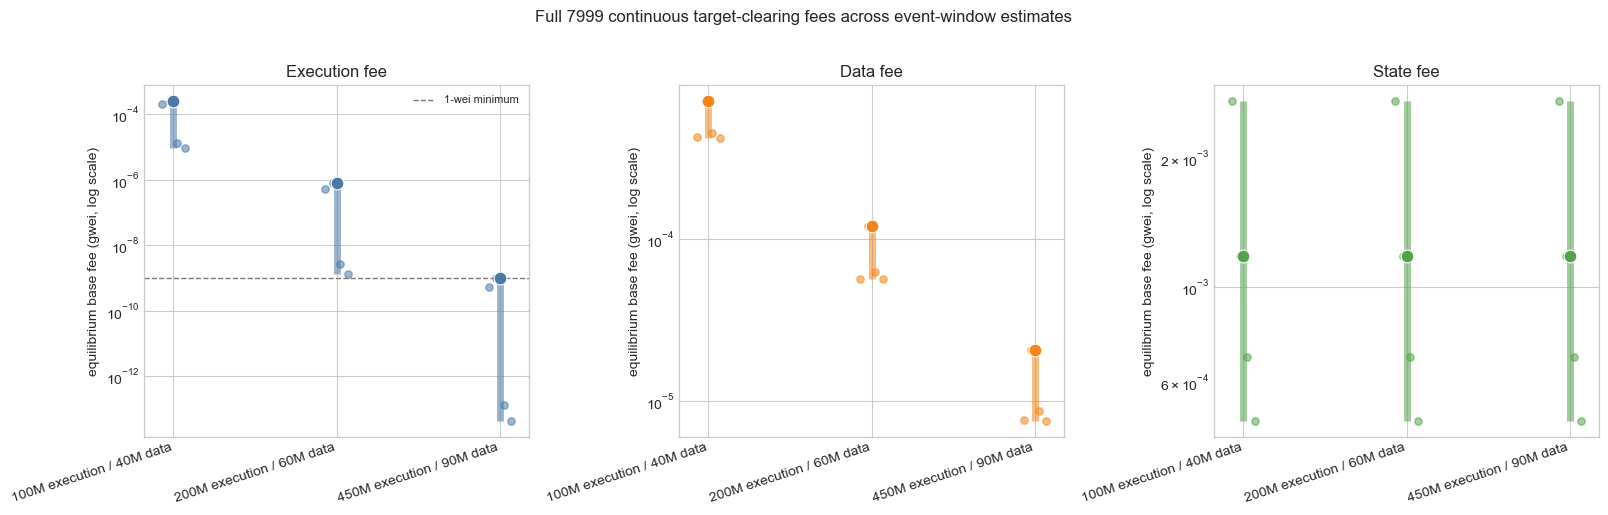

In [7]:
window_rows = results[results["paired_capacity_scenario"]].copy()
window_table = window_rows.pivot_table(
    index=["scenario", "execution_gas_limit", "data_gas_limit", "window_days"],
    columns="resource", values="equilibrium_base_fee_gwei", aggfunc="first",
).reset_index().rename(columns={
    "execution": "execution_base_fee_gwei",
    "data": "data_base_fee_gwei",
    "state": "state_base_fee_gwei",
})
window_export_cols = [
    "scenario", "execution_gas_limit", "data_gas_limit",
    "window_days", "resource", "gas_target", "elasticity",
    "equilibrium_base_fee_wei_continuous", "equilibrium_base_fee_gwei",
    "protocol_base_fee_wei", "protocol_target_error_pct",
    "protocol_fee_at_minimum",
]
window_rows[window_export_cols].sort_values(
    ["scenario", "window_days", "resource"]
).to_csv(OUT_WINDOW_CSV, index=False)
display(window_table)

RESOURCE_COLORS = {"execution": "#4C78A8", "data": "#F58518", "state": "#54A24B"}
paired_order = ["E100_D40_S75", "E200_D60_S75", "E450_D90_S75"]
paired_labels = [
    "100M execution / 40M data",
    "200M execution / 60M data",
    "450M execution / 90M data",
]
fig, axes = plt.subplots(1, 3, figsize=(16.2, 5.0), sharex=True)
for ax, resource in zip(axes, RESOURCES):
    resource_rows = window_rows[window_rows["resource"].eq(resource)]
    for x_pos, scenario in enumerate(paired_order):
        values = resource_rows[resource_rows["scenario"].eq(scenario)].set_index("window_days")["equilibrium_base_fee_gwei"]
        central_value = float(values.loc[CENTRAL_WINDOW])
        ax.vlines(x_pos, values.min(), values.max(), color=RESOURCE_COLORS[resource], alpha=0.55, linewidth=5)
        jitter = np.linspace(-0.07, 0.07, len(values))
        ax.scatter(x_pos + jitter, values.values, color=RESOURCE_COLORS[resource], alpha=0.55, s=28)
        ax.scatter(x_pos, central_value, color=RESOURCE_COLORS[resource], edgecolor="white", linewidth=0.8, s=85, zorder=4)
    if resource == "execution":
        ax.axhline(MIN_BASE_FEE_WEI / GWEI, color="#777777", linestyle="--", linewidth=1, label="1-wei minimum")
        ax.legend(fontsize=8)
    ax.set_yscale("log")
    ax.set_xticks(range(len(paired_order)), paired_labels, rotation=18, ha="right")
    ax.set_title(f"{resource.capitalize()} fee")
    ax.set_ylabel("equilibrium base fee (gwei, log scale)")
fig.suptitle("Full 7999 continuous target-clearing fees across event-window estimates", y=1.02)
fig.tight_layout()
fig.savefig(PLOTS_DIR / f"full_7999_equilibrium_window_sensitivity_{DATE_LABEL}.png", dpi=160, bbox_inches="tight")
plt.show()

## BAL Amount Sensitivity

The central data anchor includes the full calibrated BAL prediction. This sweep holds the 35-day data elasticity fixed and varies BAL gas from zero to twice the calibrated amount. It changes only the data resource; execution and state fees remain unchanged under the independent model.

This is an accounting sensitivity, not an estimated BAL demand curve. A transaction-bundle model is still needed to let BAL-producing transactions respond jointly to execution, data, and state prices.

,bal_amount_ratio,data_gas_limit,data_gas_target,data_7999_gas_per_block,metering_multiplier,equilibrium_base_fee_gwei,protocol_base_fee_wei
0,0.000000,40000000,"10,000,000.000000","2,123,622.489873",1.798834,0.000069,69450
1,0.000000,60000000,"15,000,000.000000","2,123,622.489873",1.798834,0.000012,11866
2,0.000000,90000000,"22,500,000.000000","2,123,622.489873",1.798834,0.000002,2027
3,0.500000,40000000,"10,000,000.000000","3,182,614.810514",2.695863,0.000270,270179
4,0.500000,60000000,"15,000,000.000000","3,182,614.810514",2.695863,0.000046,46162
5,0.500000,90000000,"22,500,000.000000","3,182,614.810514",2.695863,0.000008,7887
6,1.000000,40000000,"10,000,000.000000","4,241,607.131155",3.592892,0.000709,708790
7,1.000000,60000000,"15,000,000.000000","4,241,607.131155",3.592892,0.000121,121103
8,1.000000,90000000,"22,500,000.000000","4,241,607.131155",3.592892,0.000021,20692
9,1.500000,40000000,"10,000,000.000000","5,300,599.451797",4.489921,0.001498,1498061


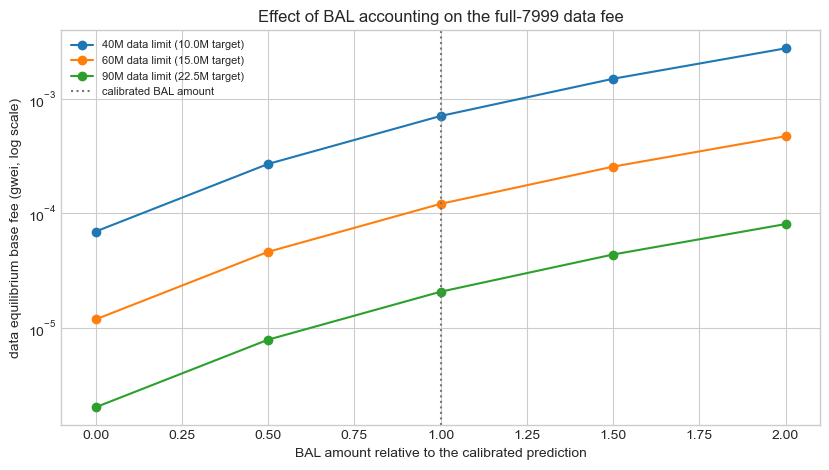

In [8]:
central_elasticity = elasticities.set_index("window_days").loc[CENTRAL_WINDOW]
BAL_AMOUNT_RATIOS = [0.0, 0.5, 1.0, 1.5, 2.0]
bal_rows = []
for bal_amount_ratio, data_limit in product(BAL_AMOUNT_RATIOS, DATA_LIMITS):
    data_7999_total = data_7999_no_bal_total + bal_amount_ratio * bal_7999_total
    data_multiplier = data_7999_total / current_data_total
    row = solve_resource(
        resource="data", elasticity=float(central_elasticity["eps_data"]),
        execution_limit=EXECUTION_LIMITS[0], data_limit=data_limit,
        metering_multiplier=data_multiplier,
    )
    row.update({
        "window_days": CENTRAL_WINDOW,
        "bal_amount_ratio": bal_amount_ratio,
        "data_gas_limit": data_limit,
        "data_gas_target": data_limit / DATA_TARGET_RATIO,
        "data_7999_gas_per_block": data_7999_total / blocks,
    })
    bal_rows.append(row)
bal_sensitivity = pd.DataFrame(bal_rows)
bal_sensitivity.to_csv(OUT_BAL_CSV, index=False)
display(bal_sensitivity[[
    "bal_amount_ratio", "data_gas_limit", "data_gas_target",
    "data_7999_gas_per_block", "metering_multiplier",
    "equilibrium_base_fee_gwei", "protocol_base_fee_wei",
]])

fig, ax = plt.subplots(figsize=(8.4, 4.8))
for data_limit, group in bal_sensitivity.groupby("data_gas_limit"):
    ax.plot(group["bal_amount_ratio"], group["equilibrium_base_fee_gwei"],
            marker="o", label=f"{data_limit/1e6:.0f}M data limit ({data_limit/DATA_TARGET_RATIO/1e6:.1f}M target)")
ax.axvline(1.0, color="#777777", linestyle=":", label="calibrated BAL amount")
ax.set_yscale("log")
ax.set_xlabel("BAL amount relative to the calibrated prediction")
ax.set_ylabel("data equilibrium base fee (gwei, log scale)")
ax.set_title("Effect of BAL accounting on the full-7999 data fee")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(PLOTS_DIR / f"full_7999_equilibrium_bal_sensitivity_{DATE_LABEL}.png", dpi=160)
plt.show()

## Interpretation And Next Step

- Full 7999 has an equilibrium **fee vector**, not one equilibrium base fee. Under independent isoelastic demand, each component depends only on its own target, metering conversion, and elasticity.
- The 3-by-3 execution/data capacity grid is deliberate. It separates the effect of the execution limit from the effect of the propagation-derived data limit; the paired 100M/40M, 200M/60M, and 450M/90M cases are selected summaries, not pairings mechanically implied by propagation.
- In the `glamsterdam_plus_8279` diagnostic, the 450M execution block can imply more than 90M candidate data gas. Under full 7999 this is not an inconsistency: the separate 90M data limit becomes the binding payload backstop before execution reaches its maximum.
- BAL bytes must be included in the data accounting. In the calibrated 120-day anchor they are a large fraction of candidate data gas, so omitting them materially changes the data fee. Assigning all BAL gas the data elasticity is not empirically identified: BAL-producing transactions should ultimately respond jointly to execution, data, and state prices.
- Execution currently uses $m_{\mathrm{execution}}=1$. EIP-8038 would increase regular-gas charges for selected state-access and state-write operations rather than multiplying all execution uniformly. A final post-Glamsterdam comparison should reprice those operations consistently in both G0 and full 7999. Until that accounting is available, the 100M and 200M results isolate fee-market separation under unchanged execution metering.
- The state resource clears a 75M target and has no hard limit. Its equilibrium fee is therefore identical across execution/data capacity cases within a given elasticity calibration.
- At the 450M execution limit, all four continuous target-clearing fees fall below the 1-wei protocol minimum. The central 35-day case is only slightly below it (0.996 wei): at 1 wei, predicted execution use is 224.89M against the 225M target. The other windows leave more unused execution capacity at the floor. These are floor-constrained outcomes under $m_{\mathrm{execution}}=1$, so the conclusion is conditional on omitting EIP-8038 repricing.
- The earlier integer issue also remains at 200M under the 75-day estimate: its continuous fee is 1.32 wei, so a dynamic simulation must determine the path between available integer fees.
- Reserve pricing, transaction-resource coupling, limit hits, fee volatility, and shock recovery are outside this steady-state notebook. The next notebook should warm-start G0 and full 7999 at these equilibria and expose both mechanisms to the same demand shocks.